<a href="https://colab.research.google.com/github/sharath0899/projects/blob/main/semaglutide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PHASE 2**

#STEP-1 FAERS Data

In [ ]:
import requests
import pandas as pd

# API endpoint
url = "https://api.fda.gov/drug/event.json"

params = {
    "search": 'patient.drug.medicinalproduct:"SEMAGLUTIDE"',
    "count": "patient.reaction.reactionmeddrapt.exact",
    "limit": 100
}

response = requests.get(url, params=params)
data = response.json()

# Convert to dataframe
results = data['results']
df = pd.DataFrame(results)

df.columns = ['Adverse_Event', 'Count']

df.head()

,Adverse_Event,Count
0,NAUSEA,862
1,VOMITING,750
2,DIARRHOEA,537
3,OFF LABEL USE,362
4,FATIGUE,360


#STEP-2 Clean the Data

In [ ]:
# Convert event names to lowercase (for matching later)
df['Adverse_Event'] = df['Adverse_Event'].str.lower()

# Sort by count
df = df.sort_values(by='Count', ascending=False)

df.head(20)

,Adverse_Event,Count
0,nausea,862
1,vomiting,750
2,diarrhoea,537
3,off label use,362
4,fatigue,360
5,weight decreased,360
6,dyspnoea,353
7,drug ineffective,340
8,dizziness,288
9,headache,276


#STEP-3 Keep Only Relevant Events (Match with RCT)

In [ ]:
rct_events = [
    "nausea", "vomiting", "diarrhea", "constipation",
    "abdominal pain", "dyspepsia", "hypoglycemia",
    "pancreatitis", "gallbladder disease",
    "fatigue", "headache", "dizziness"
]

filtered_df = df[df['Adverse_Event'].isin(rct_events)]

filtered_df

,Adverse_Event,Count
0,nausea,862
1,vomiting,750
4,fatigue,360
8,dizziness,288
9,headache,276
12,abdominal pain,232
13,constipation,231
31,pancreatitis,147
89,dyspepsia,76


improve matching

In [ ]:
df['Adverse_Event'] = df['Adverse_Event'].replace({
    "diarrhoea": "diarrhea",
    "abdominal pain upper": "abdominal pain",
    "cholelithiasis": "gallbladder disease"
})

#STEP-4 Save the Dataset

In [ ]:
filtered_df.to_csv("semaglutide_faers_filtered.csv", index=False)

#STEP-5 Visualization

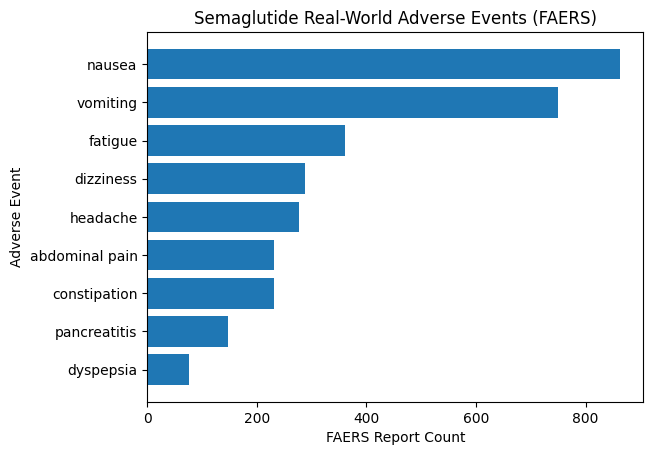

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(filtered_df['Adverse_Event'], filtered_df['Count'])
plt.xlabel("FAERS Report Count")
plt.ylabel("Adverse Event")
plt.title("Semaglutide Real-World Adverse Events (FAERS)")
plt.gca().invert_yaxis()
plt.show()

#**PHASE 3**

semaglutide raw data to csv

In [ ]:
import pandas as pd

data = {
    "adverse_event": ["nausea","vomiting","diarrhea","constipation","abdominal pain",
                      "dyspepsia","gastroesophageal reflux disease","hypoglycemia",
                      "fatigue","headache","dizziness","decreased appetite",
                      "pancreatitis","gallbladder disease","acute kidney injury","retinopathy"],
    "semaglutide_rate": [44,24,30,24,10,7,5,6,8,9,5,12,1,2,1,7],
    "placebo_rate": [17,6,16,11,4,3,2,3,5,6,3,4,0,1,0.5,6]
}

df = pd.DataFrame(data)
df.to_csv("semaglutide_rct_data.csv", index=False)

print("File created!")

File created!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# STEP 1: LOAD TWO DATASETS

In [ ]:
# 1. semaglutide_rct_data.csv
# 2. semaglutide_faers_filtered.csv

rct_df = pd.read_csv("semaglutide_rct_data.csv")
faers_df = pd.read_csv("semaglutide_faers_filtered.csv")

print("RCT Data Preview:")
print(rct_df.head())

print("\nFAERS Data Preview:")
print(faers_df.head())


RCT Data Preview:
    adverse_event  semaglutide_rate  placebo_rate
0          nausea                44          17.0
1        vomiting                24           6.0
2        diarrhea                30          16.0
3    constipation                24          11.0
4  abdominal pain                10           4.0

FAERS Data Preview:
  Adverse_Event  Count
0        nausea    862
1      vomiting    750
2       fatigue    360
3     dizziness    288
4      headache    276


# STEP 2: CLEAN COLUMN NAMES

In [ ]:
rct_df.columns = rct_df.columns.str.strip().str.lower()
faers_df.columns = faers_df.columns.str.strip().str.lower()

# Expected RCT columns:
# adverse_event, semaglutide_rate, placebo_rate
# Expected FAERS columns:
# adverse_event, count

print("\nRCT Columns:", rct_df.columns.tolist())
print("FAERS Columns:", faers_df.columns.tolist())



RCT Columns: ['adverse_event', 'semaglutide_rate', 'placebo_rate']
FAERS Columns: ['adverse_event', 'count']


# STEP 3: STANDARDIZE ADVERSE EVENT NAMES

In [ ]:
rct_df["adverse_event"] = rct_df["adverse_event"].str.strip().str.lower()
faers_df["adverse_event"] = faers_df["adverse_event"].str.strip().str.lower()

# Optional mapping to make names match better
event_mapping = {
    "diarrhoea": "diarrhea",
    "abdominal pain upper": "abdominal pain",
    "cholelithiasis": "gallbladder disease",
    "gastrooesophageal reflux disease": "gastroesophageal reflux disease"
}

rct_df["adverse_event"] = rct_df["adverse_event"].replace(event_mapping)
faers_df["adverse_event"] = faers_df["adverse_event"].replace(event_mapping)


# STEP 4: CONVERT PERCENTAGES TO PROPORTIONS

In [ ]:
#  semaglutide_rate and placebo_rate are percentages are 44, 17
# converted them to proportions like 0.44, 0.17

rct_df["trial_rate"] = rct_df["semaglutide_rate"] / 100
rct_df["placebo_rate_prop"] = rct_df["placebo_rate"] / 100

# Optional additional metric: risk difference
rct_df["risk_difference"] = rct_df["trial_rate"] - rct_df["placebo_rate_prop"]



# STEP 5: NORMALIZE FAERS COUNTS

In [ ]:
total_faers_reports = faers_df["count"].sum()
faers_df["faers_rate"] = faers_df["count"] / total_faers_reports


# STEP 6: MERGE RCT + FAERS DATA

In [ ]:
merged_df = pd.merge(
    rct_df,
    faers_df,
    on="adverse_event",
    how="inner"
)

print("\nMerged Data:")
print(merged_df.head())



Merged Data:
    adverse_event  semaglutide_rate  placebo_rate  trial_rate  \
0          nausea                44          17.0        0.44   
1        vomiting                24           6.0        0.24   
2    constipation                24          11.0        0.24   
3  abdominal pain                10           4.0        0.10   
4       dyspepsia                 7           3.0        0.07   

   placebo_rate_prop  risk_difference  count  faers_rate  
0               0.17             0.27    862    0.267536  
1               0.06             0.18    750    0.232775  
2               0.11             0.13    231    0.071695  
3               0.04             0.06    232    0.072005  
4               0.03             0.04     76    0.023588  


# STEP 7: CALCULATE DIVERGENCE SCORE

In [ ]:
# Simple divergence score:
# FAERS proportion - trial proportion

merged_df["divergence_score"] = merged_df["faers_rate"] - merged_df["trial_rate"]

# Absolute divergence can also be useful
merged_df["absolute_divergence"] = merged_df["divergence_score"].abs()

# Sort by highest absolute divergence
merged_df = merged_df.sort_values(by="absolute_divergence", ascending=False)

print("\nFinal Divergence Table:")
print(merged_df[
    [
        "adverse_event",
        "trial_rate",
        "placebo_rate_prop",
        "risk_difference",
        "count",
        "faers_rate",
        "divergence_score",
        "absolute_divergence"
    ]
])



Final Divergence Table:
    adverse_event  trial_rate  placebo_rate_prop  risk_difference  count  \
0          nausea        0.44               0.17             0.27    862   
2    constipation        0.24               0.11             0.13    231   
4       dyspepsia        0.07               0.03             0.04     76   
7       dizziness        0.05               0.03             0.02    288   
8    pancreatitis        0.01               0.00             0.01    147   
5         fatigue        0.08               0.05             0.03    360   
3  abdominal pain        0.10               0.04             0.06    232   
1        vomiting        0.24               0.06             0.18    750   
6        headache        0.09               0.06             0.03    276   

   faers_rate  divergence_score  absolute_divergence  
0    0.267536         -0.172464             0.172464  
2    0.071695         -0.168305             0.168305  
4    0.023588         -0.046412             0.046

# STEP 8: INTERPRETATION LABELS

In [ ]:
def interpret_divergence(score):
    if score > 0:
        return "Higher in FAERS"
    elif score < 0:
        return "Higher in Clinical Trials"
    else:
        return "Similar"

merged_df["interpretation"] = merged_df["divergence_score"].apply(interpret_divergence)

print("\nInterpretation:")
print(merged_df[["adverse_event", "divergence_score", "interpretation"]])



Interpretation:
    adverse_event  divergence_score             interpretation
0          nausea         -0.172464  Higher in Clinical Trials
2    constipation         -0.168305  Higher in Clinical Trials
4       dyspepsia         -0.046412  Higher in Clinical Trials
7       dizziness          0.039385            Higher in FAERS
8    pancreatitis          0.035624            Higher in FAERS
5         fatigue          0.031732            Higher in FAERS
3  abdominal pain         -0.027995  Higher in Clinical Trials
1        vomiting         -0.007225  Higher in Clinical Trials
6        headache         -0.004339  Higher in Clinical Trials


# STEP 9: SAVE FINAL RESULTS

In [ ]:
merged_df.to_csv("semaglutide_phase3_divergence_results.csv", index=False)
print("\nSaved: semaglutide_phase3_divergence_results.csv")



Saved: semaglutide_phase3_divergence_results.csv


# STEP 10: BAR CHART OF DIVERGENCE

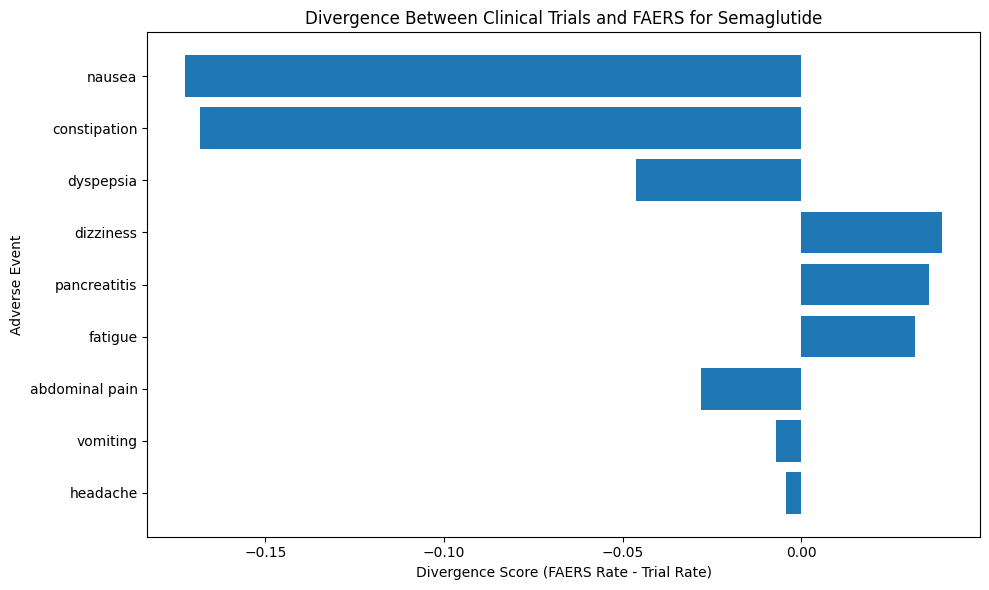

In [ ]:
top_plot_df = merged_df.sort_values(by="absolute_divergence", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_plot_df["adverse_event"], top_plot_df["divergence_score"])
plt.xlabel("Divergence Score (FAERS Rate - Trial Rate)")
plt.ylabel("Adverse Event")
plt.title("Divergence Between Clinical Trials and FAERS for Semaglutide")
plt.tight_layout()
plt.show()

# STEP 11: SCATTER PLOT

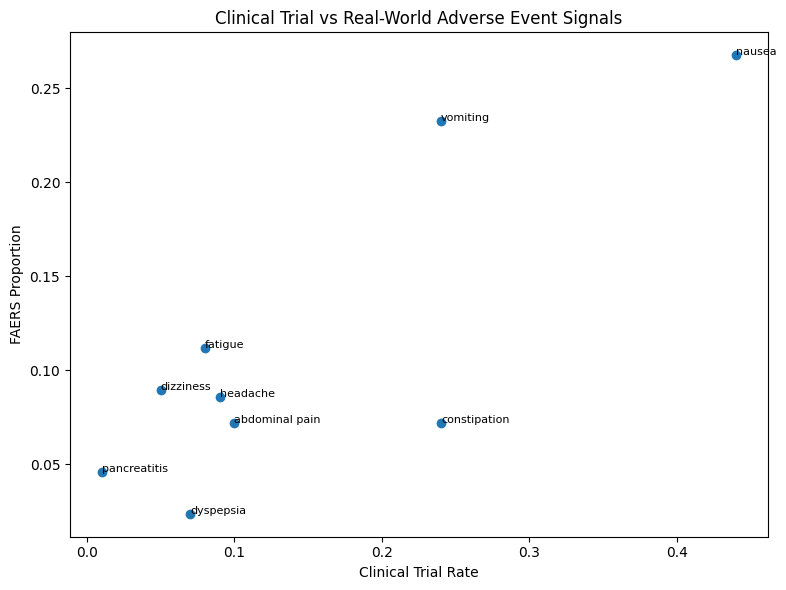

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(merged_df["trial_rate"], merged_df["faers_rate"])

for _, row in merged_df.iterrows():
    plt.text(row["trial_rate"], row["faers_rate"], row["adverse_event"], fontsize=8)

plt.xlabel("Clinical Trial Rate")
plt.ylabel("FAERS Proportion")
plt.title("Clinical Trial vs Real-World Adverse Event Signals")
plt.tight_layout()
plt.show()

# STEP 12: OPTIONAL HEATMAP-LIKE TABLE VIEW

In [ ]:
heatmap_df = merged_df[
    [
        "adverse_event",
        "trial_rate",
        "placebo_rate_prop",
        "risk_difference",
        "faers_rate",
        "divergence_score"
    ]
].copy()

print("\nHeatmap-style Summary Table:")
print(heatmap_df)


Heatmap-style Summary Table:
    adverse_event  trial_rate  placebo_rate_prop  risk_difference  faers_rate  \
0          nausea        0.44               0.17             0.27    0.267536   
2    constipation        0.24               0.11             0.13    0.071695   
4       dyspepsia        0.07               0.03             0.04    0.023588   
7       dizziness        0.05               0.03             0.02    0.089385   
8    pancreatitis        0.01               0.00             0.01    0.045624   
5         fatigue        0.08               0.05             0.03    0.111732   
3  abdominal pain        0.10               0.04             0.06    0.072005   
1        vomiting        0.24               0.06             0.18    0.232775   
6        headache        0.09               0.06             0.03    0.085661   

   divergence_score  
0         -0.172464  
2         -0.168305  
4         -0.046412  
7          0.039385  
8          0.035624  
5          0.031732  
3    

#Phase 4 — Visualization

1. Bar Chart — Divergence

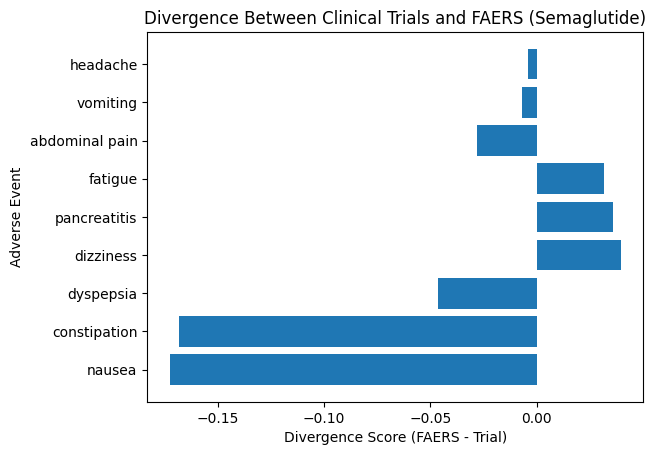

In [ ]:
import matplotlib.pyplot as plt

# Sort for better visualization
plot_df = merged_df.sort_values(by="absolute_divergence", ascending=True)

plt.figure()
plt.barh(plot_df["adverse_event"], plot_df["divergence_score"])
plt.xlabel("Divergence Score (FAERS - Trial)")
plt.ylabel("Adverse Event")
plt.title("Divergence Between Clinical Trials and FAERS (Semaglutide)")
plt.gca().invert_yaxis()
plt.show()

# Interpretation:
Negative values (left side):
Nausea, constipation, dyspepsia → more common in clinical trials

Positive values (right side):
Dizziness, pancreatitis, fatigue → more common in real-world (FAERS)

Near zero:
Headache, vomiting → similar in both

2. Scatter Plot — Trial vs Real World

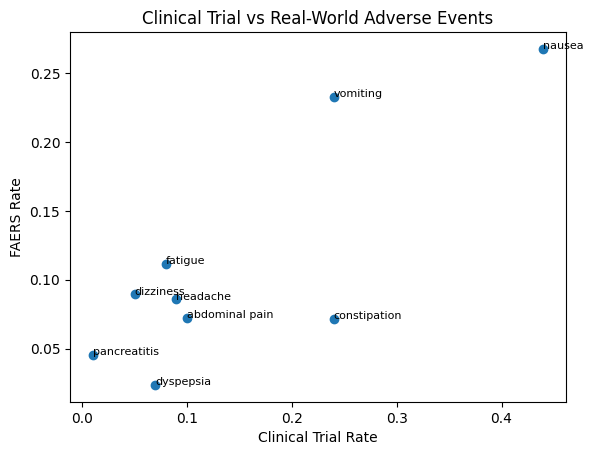

In [ ]:
plt.figure()

plt.scatter(merged_df["trial_rate"], merged_df["faers_rate"])

for i, row in merged_df.iterrows():
    plt.text(row["trial_rate"], row["faers_rate"], row["adverse_event"], fontsize=8)

plt.xlabel("Clinical Trial Rate")
plt.ylabel("FAERS Rate")
plt.title("Clinical Trial vs Real-World Adverse Events")
plt.show()

# Interpretation:
Points show trial rate (x-axis) vs FAERS rate (y-axis)

If both are similar → point lies near a diagonal trend

Key Insights:
Nausea, vomiting: high in both → consistent reporting

Constipation: high in trials but lower in FAERS → trial-heavy

Fatigue, dizziness: relatively higher in FAERS → real-world signal

Pancreatitis: low in trials but appears in FAERS → important safety signal

3. Top FAERS Events Chart


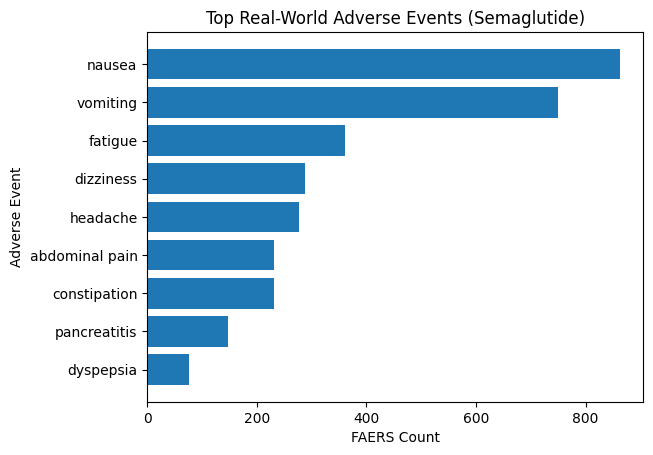

In [ ]:
top_faers = faers_df.sort_values(by="count", ascending=False).head(10)

plt.figure()
plt.barh(top_faers["adverse_event"], top_faers["count"])
plt.xlabel("FAERS Count")
plt.ylabel("Adverse Event")
plt.title("Top Real-World Adverse Events (Semaglutide)")
plt.gca().invert_yaxis()
plt.show()

# Interpretation:
Most common real-world adverse events:
Nausea > Vomiting > Fatigue > Dizziness

Moderate:
Headache, abdominal pain, constipation

Less common but important:
Pancreatitis, dyspepsia

Gastrointestinal issues (nausea, vomiting) dominate in real-world data, while serious events like pancreatitis, though less frequent, are clinically important safety signals.

4. Heatmap-style Table

In [ ]:
print(merged_df[[
    "adverse_event",
    "trial_rate",
    "faers_rate",
    "divergence_score"
]])

    adverse_event  trial_rate  faers_rate  divergence_score
0          nausea        0.44    0.267536         -0.172464
2    constipation        0.24    0.071695         -0.168305
4       dyspepsia        0.07    0.023588         -0.046412
7       dizziness        0.05    0.089385          0.039385
8    pancreatitis        0.01    0.045624          0.035624
5         fatigue        0.08    0.111732          0.031732
3  abdominal pain        0.10    0.072005         -0.027995
1        vomiting        0.24    0.232775         -0.007225
6        headache        0.09    0.085661         -0.004339


# Interpretation
Highest trial rates: nausea (0.44), constipation (0.24)

Higher in FAERS: dizziness, pancreatitis, fatigue

Negative divergence: nausea, constipation → more in trials

Positive divergence: pancreatitis, dizziness → more in real-world

Near zero: vomiting, headache → similar in both

Some side effects are overrepresented in trials, while real-world data reveals additional safety signals, especially pancreatitis and dizziness.


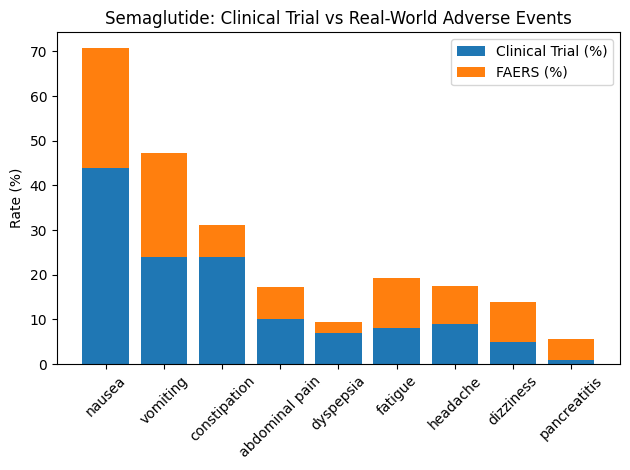

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load FAERS data (your filtered file)
faers = pd.read_csv("semaglutide_faers_filtered.csv")

# Normalize FAERS counts (convert to percentage)
faers['FAERS_rate'] = (faers['Count'] / faers['Count'].sum()) * 100

# RCT data (you already created)
rct_data = pd.DataFrame({
    "adverse_event": ["nausea","vomiting","diarrhea","constipation","abdominal pain",
                      "dyspepsia","hypoglycemia","fatigue","headache","dizziness",
                      "pancreatitis","gallbladder disease"],
    "semaglutide_rate": [44,24,30,24,10,7,6,8,9,5,1,2]
})

# Merge FAERS + RCT
merged = pd.merge(rct_data, faers, left_on="adverse_event", right_on="Adverse_Event", how="inner")

# Plot comparison
x = merged['adverse_event']
x_pos = range(len(x))

plt.figure()

plt.bar(x_pos, merged['semaglutide_rate'], label="Clinical Trial (%)")
plt.bar(x_pos, merged['FAERS_rate'], bottom=merged['semaglutide_rate'], label="FAERS (%)")

plt.xticks(x_pos, x, rotation=45)
plt.ylabel("Rate (%)")
plt.title("Semaglutide: Clinical Trial vs Real-World Adverse Events")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("figure1_divergence.png", dpi=300)

<Figure size 640x480 with 0 Axes>

#***Figure 1 — Divergence Score Bar Chart***

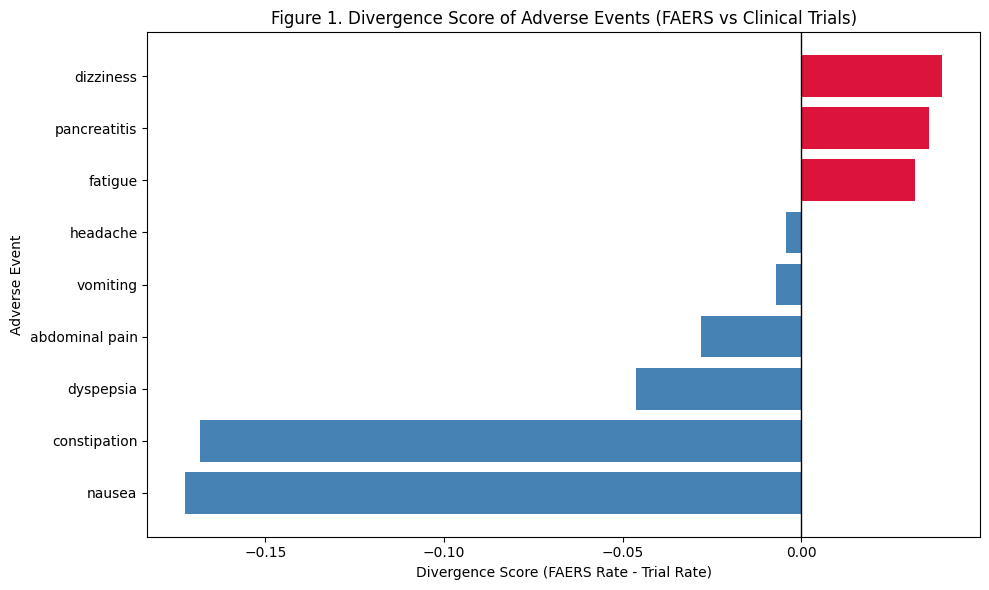

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load divergence results
div_df = pd.read_csv("semaglutide_phase3_divergence_results.csv")

# Clean event names
div_df["adverse_event"] = div_df["adverse_event"].astype(str).str.strip().str.lower()

# Sort by divergence score
fig1_df = div_df.sort_values("divergence_score", ascending=True)

# Color bars by direction
bar_colors = ["crimson" if x > 0 else "steelblue" for x in fig1_df["divergence_score"]]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(fig1_df["adverse_event"], fig1_df["divergence_score"], color=bar_colors)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Divergence Score (FAERS Rate - Trial Rate)")
plt.ylabel("Adverse Event")
plt.title("Figure 1. Divergence Score of Adverse Events (FAERS vs Clinical Trials)")

plt.tight_layout()
plt.savefig("figure1_divergence_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

**What this figure shows**

This figure compares the difference between FAERS reporting and clinical trial reporting for each matched adverse event.

Positive score → event reported more in FAERS

Negative score → event reported more in clinical trials

Interpretation

This figure helps identify which adverse events are more prominent in real-world reporting and which are more prominent in controlled trial settings.

For semaglutide, events with positive divergence may represent signals that become more visible in broader real-world populations, where patients may have multiple comorbidities, different adherence patterns, and polypharmacy. Events with negative divergence are likely better captured in clinical trials, especially common expected side effects such as gastrointestinal symptoms.

Caption

Figure 1. Divergence Score of Adverse Events (FAERS vs Clinical Trials).

This figure presents the divergence score for each matched adverse event, calculated as FAERS reporting rate minus clinical trial reporting rate. Positive values indicate stronger reporting in real-world data, while negative values indicate stronger reporting in clinical trials.

#**Figure 2 — Scatter Plot of Trial Rate vs FAERS**

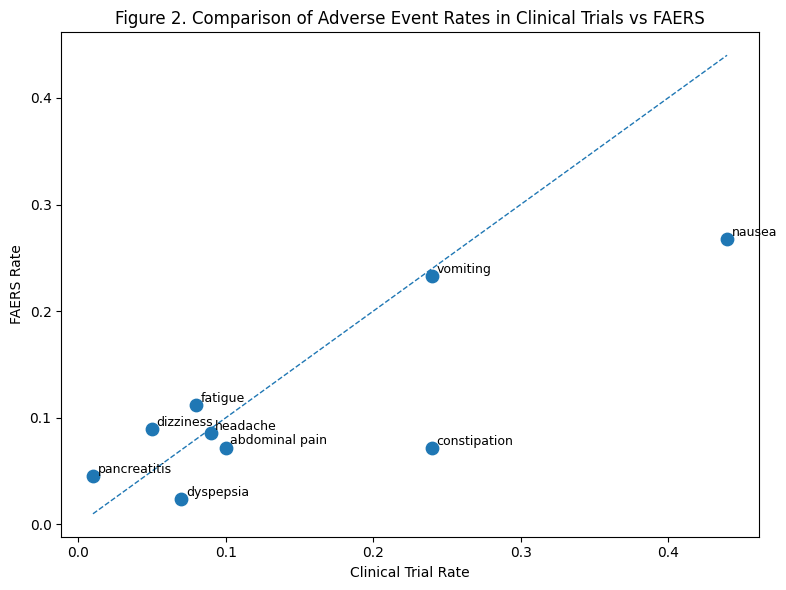

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load divergence data
div_df = pd.read_csv("semaglutide_phase3_divergence_results.csv")

# Clean event names
div_df["adverse_event"] = div_df["adverse_event"].astype(str).str.strip().str.lower()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(div_df["trial_rate"], div_df["faers_rate"], s=80)

# Add labels
for _, row in div_df.iterrows():
    plt.text(
        row["trial_rate"] + 0.003,
        row["faers_rate"] + 0.003,
        row["adverse_event"],
        fontsize=9
    )

# Diagonal reference line
min_val = min(div_df["trial_rate"].min(), div_df["faers_rate"].min())
max_val = max(div_df["trial_rate"].max(), div_df["faers_rate"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

plt.xlabel("Clinical Trial Rate")
plt.ylabel("FAERS Rate")
plt.title("Figure 2. Comparison of Adverse Event Rates in Clinical Trials vs FAERS")

plt.tight_layout()
plt.savefig("figure2_scatter_trial_vs_faers.png", dpi=300, bbox_inches="tight")
plt.show()

**What this figure shows**

This figure compares the same adverse events across two sources:

x-axis = clinical trial rate

y-axis = FAERS rate

The diagonal line is the equal reporting line.

Points above the line → reported more in FAERS

Points below the line → reported more in clinical trials

**Interpretation**

This figure visually shows the overall agreement or mismatch between controlled trials and real-world pharmacovigilance data.

If many points are far from the diagonal line, that means the two data sources are capturing different safety patterns. In your project, this supports the idea that clinical trial data and FAERS data are complementary rather than identical. It also helps identify possible real-world dominant events that deserve closer post-marketing attention.

**Caption**
Figure 2. Comparison of Adverse Event Rates in Clinical Trials vs FAERS.

Each point represents a matched adverse event. Events above the diagonal line are more frequently reported in FAERS, while events below the line are more frequent in clinical trials.

#**Figure 3 — Top FAERS Adverse Events**

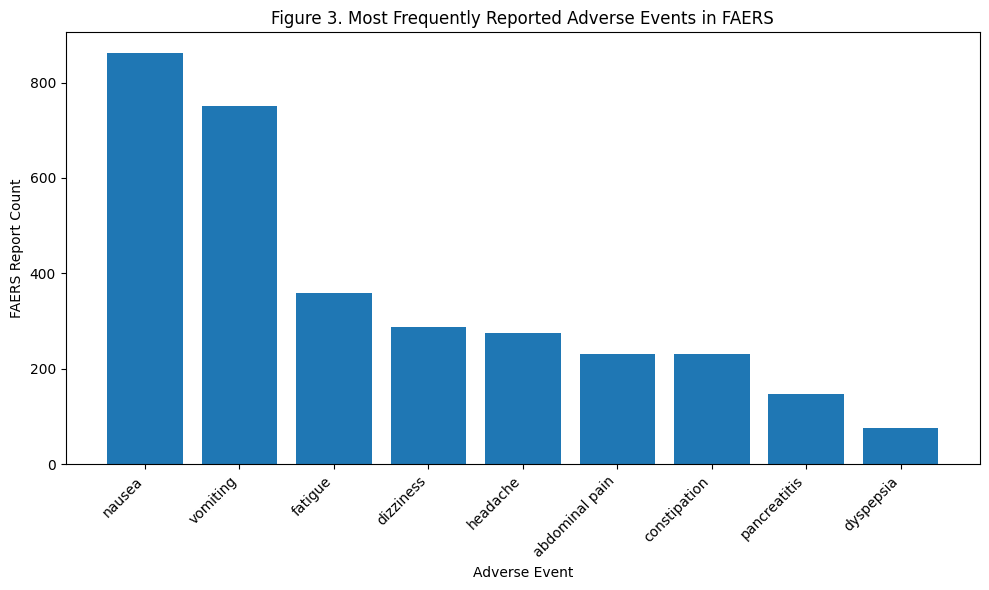

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load FAERS data
faers_df = pd.read_csv("semaglutide_faers_filtered.csv")

# Clean event names
faers_df["Adverse_Event"] = faers_df["Adverse_Event"].astype(str).str.strip().str.lower()

# Sort by count
fig3_df = faers_df.sort_values("Count", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(fig3_df["Adverse_Event"], fig3_df["Count"])

plt.xlabel("Adverse Event")
plt.ylabel("FAERS Report Count")
plt.title("Figure 3. Most Frequently Reported Adverse Events in FAERS")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figure3_top_faers_events.png", dpi=300, bbox_inches="tight")
plt.show()

**What this figure shows**

This figure displays the most frequently reported adverse events in the FAERS dataset for semaglutide.

It gives a direct view of the real-world reporting burden for each event.

**Interpretation**

This figure highlights which adverse events are most prominent after drug use in broader routine care settings. If gastrointestinal events dominate, that confirms known tolerability issues. If systemic or serious events such as fatigue, dizziness, or pancreatitis appear prominently, that may indicate clinically important post-marketing safety signals.

This figure is important because it does not compare with trials directly. Instead, it first shows the real-world safety profile on its own.

**Caption**

**Figure 3. Most Frequently Reported Adverse Events in FAERS.**

This bar chart shows the most commonly reported semaglutide adverse events in FAERS, highlighting dominant real-world safety signals.

#**Figure 4 — Top Positive and Negative Divergence Signals**

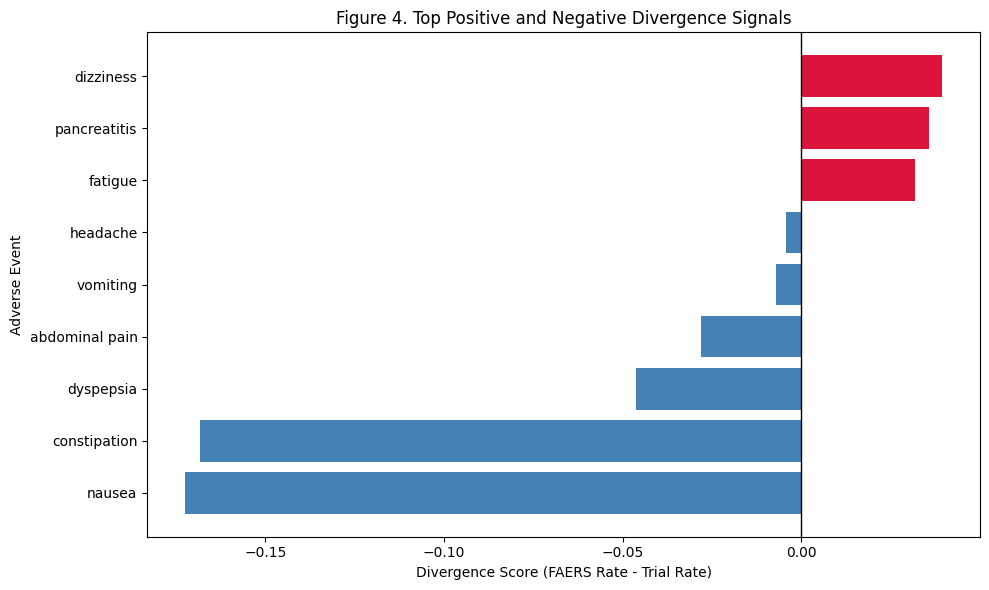

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load divergence data
div_df = pd.read_csv("semaglutide_phase3_divergence_results.csv")

# Clean event names
div_df["adverse_event"] = div_df["adverse_event"].astype(str).str.strip().str.lower()

# Sort by divergence score
sorted_df = div_df.sort_values("divergence_score", ascending=False)

# Select top positive and top negative divergence events
top_positive = sorted_df.head(5)
top_negative = sorted_df.tail(5)

# Combine
fig4_df = pd.concat([top_negative, top_positive]).drop_duplicates().sort_values("divergence_score")

# Color bars
colors = ["crimson" if x > 0 else "steelblue" for x in fig4_df["divergence_score"]]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(fig4_df["adverse_event"], fig4_df["divergence_score"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Divergence Score (FAERS Rate - Trial Rate)")
plt.ylabel("Adverse Event")
plt.title("Figure 4. Top Positive and Negative Divergence Signals")

plt.tight_layout()
plt.savefig("figure4_top_divergence_signals.png", dpi=300, bbox_inches="tight")
plt.show()

**What this figure shows**

This figure focuses only on the strongest divergence signals from both sides:

most FAERS-dominant events

most trial-dominant events

This is a cleaner summary figure for publication.

**Interpretation**

This figure is useful because it highlights the most clinically important mismatches between controlled and real-world safety evidence. Positive divergence signals may suggest under-recognition in trials or emergence in broader populations, while negative divergence signals may reflect events that are closely monitored and more consistently elicited in trials.

This figure supports your central research message that real-world pharmacovigilance can reveal safety patterns that may not be fully captured during pre-approval studies.

**Caption**

**Figure 4. Top Positive and Negative Divergence Signals.**

This figure highlights the adverse events with the highest positive and negative divergence scores. Positive divergence suggests stronger reporting in FAERS, while negative divergence suggests higher prominence in clinical trials.


#**Optional Figure 5 — Absolute Divergence Magnitude**

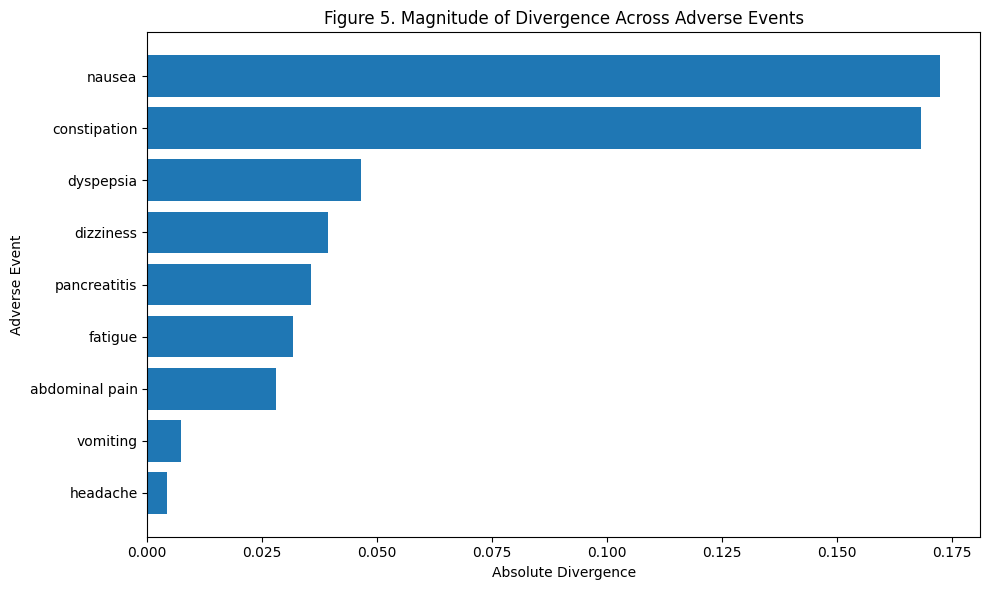

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load divergence data
div_df = pd.read_csv("semaglutide_phase3_divergence_results.csv")

# Clean event names
div_df["adverse_event"] = div_df["adverse_event"].astype(str).str.strip().str.lower()

# If absolute_divergence column is not already present, create it
if "absolute_divergence" not in div_df.columns:
    div_df["absolute_divergence"] = div_df["divergence_score"].abs()

# Sort by magnitude
fig5_df = div_df.sort_values("absolute_divergence", ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(fig5_df["adverse_event"], fig5_df["absolute_divergence"])

plt.xlabel("Absolute Divergence")
plt.ylabel("Adverse Event")
plt.title("Figure 5. Magnitude of Divergence Across Adverse Events")

plt.tight_layout()
plt.savefig("figure5_absolute_divergence.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation**

This figure shows which adverse events differ the most between clinical trials and FAERS, regardless of whether they are trial-dominant or FAERS-dominant. It is helpful for prioritizing events for further statistical testing, validation, or safety review.

**Caption**

**Figure 5. Magnitude of Divergence Across Adverse Events.**

This figure presents the absolute divergence for each matched adverse event, highlighting the largest discrepancies between clinical trial and FAERS reporting regardless of direction.